# 📊 Data Analysis - Students Performance
تحلیل آماری و گرافیکی داده‌های نمرات دانش‌آموزان با استفاده از پایتون


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Load dataset
df = pd.read_csv("StudentsPerformance.csv")

# نمایش 5 سطر اول برای بررسی
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## ℹ️ اطلاعات اولیه دیتاست


In [2]:
print("شکل داده‌ها:", df.shape)
print("\nنوع داده‌ها:\n", df.dtypes)
print("\nآمار توصیفی:\n", df.describe())


شکل داده‌ها: (1000, 8)

نوع داده‌ها:
 gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

آمار توصیفی:
        math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000


## 📌 محاسبه آماره‌های آماری (Five-number summary, IQR, Range, Variance, Std)


In [3]:
numeric_cols = ['math score', 'reading score', 'writing score']  # اصلاح کن اگر بیشتر هست

for col in numeric_cols:
    print(f"\n--- آماره‌ها برای ستون: {col} ---")
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    range_ = df[col].max() - df[col].min()
    variance = df[col].var()
    std_dev = df[col].std()
    
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Range: {range_}")
    print(f"Variance: {variance}")
    print(f"Standard Deviation: {std_dev}")



--- آماره‌ها برای ستون: math score ---
Q1: 57.0
Q3: 77.0
IQR: 20.0
Range: 100
Variance: 229.91899799799796
Standard Deviation: 15.16308009600945

--- آماره‌ها برای ستون: reading score ---
Q1: 59.0
Q3: 79.0
IQR: 20.0
Range: 83
Variance: 213.16560460460462
Standard Deviation: 14.600191937252216

--- آماره‌ها برای ستون: writing score ---
Q1: 57.75
Q3: 79.0
IQR: 21.25
Range: 90
Variance: 230.907991991992
Standard Deviation: 15.19565701086965


## 📦 Boxplot (نمودار جعبه‌ای برای مقایسه ستون‌ها)


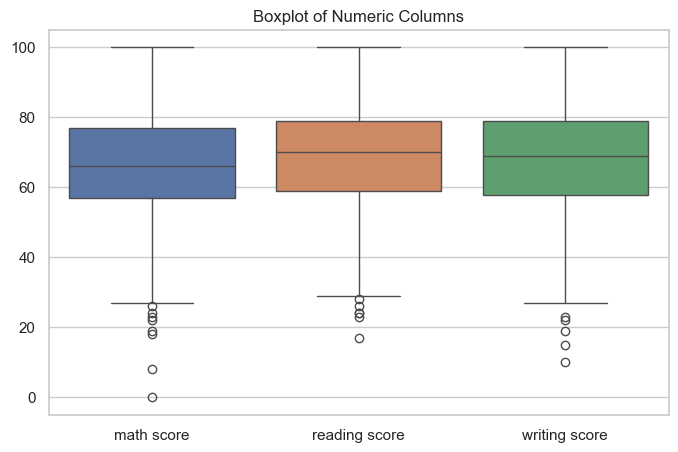

In [4]:
sns.set(style="whitegrid")
plt.figure(figsize=(8,5))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot of Numeric Columns")
plt.show()


## 📈 Quantile Plot (نمودار کوانتایل)


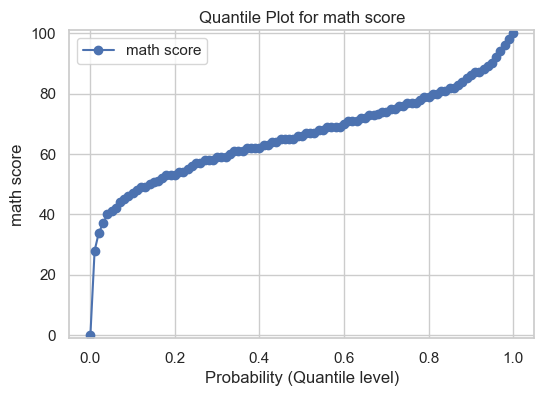

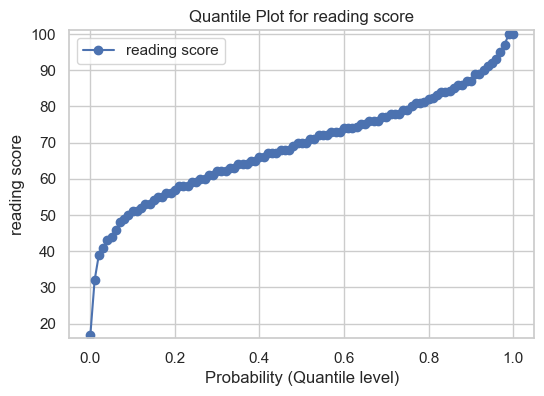

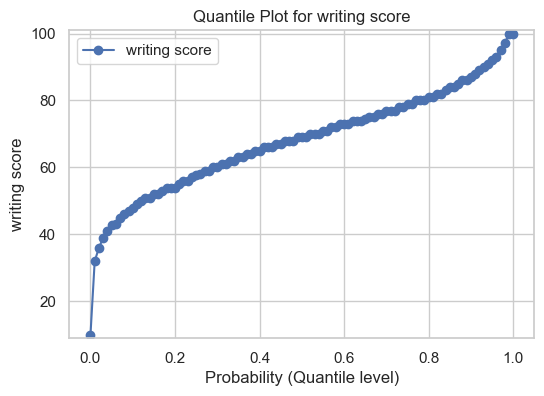

In [5]:
probs = np.linspace(0, 1, 101)  # کوانتایل از 0 تا 100 درصد
sns.set_style("whitegrid")

for col in numeric_cols:
    qs = df[col].quantile(probs)
    
    plt.figure(figsize=(6,4))
    plt.plot(probs, qs, marker='o', linestyle='-', label=col)
    plt.title(f'Quantile Plot for {col}')
    plt.xlabel('Probability (Quantile level)')
    plt.ylabel(col)
    plt.ylim(df[col].min() - 1, df[col].max() + 1)
    plt.legend()
    plt.show()


## 🟪 Q-Q Plot (برای بررسی نرمال بودن داده‌ها)


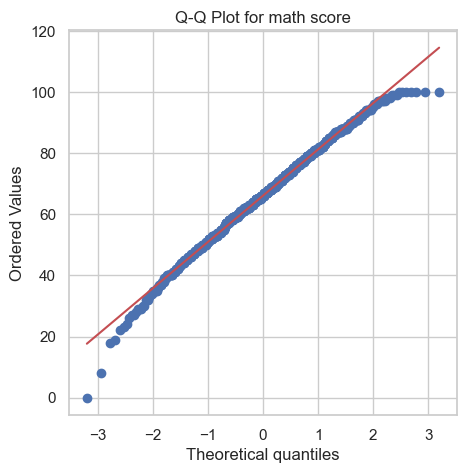

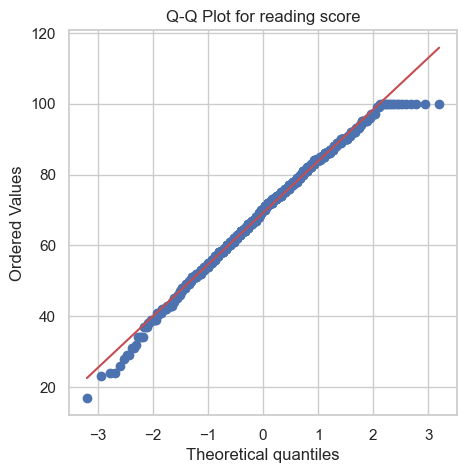

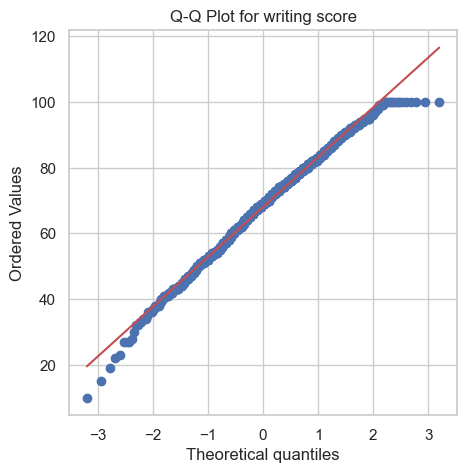

In [6]:
for col in numeric_cols:
    plt.figure(figsize=(5,5))
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f"Q-Q Plot for {col}")
    plt.grid(True)
    plt.show()


## 📊 Histogram (نمودار هیستوگرام برای توزیع داده‌ها)


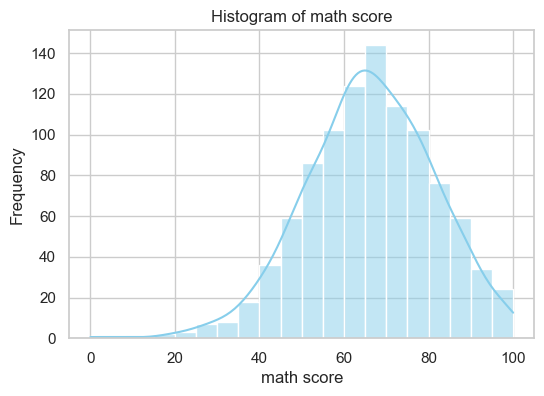

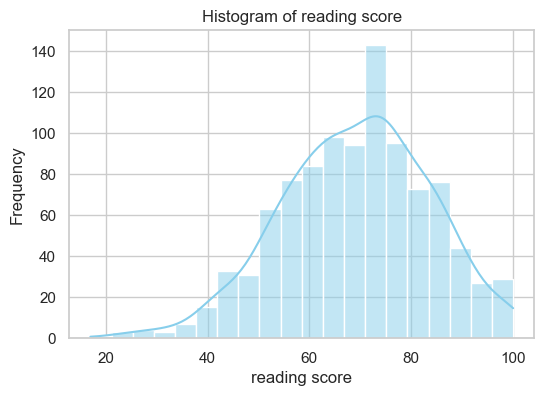

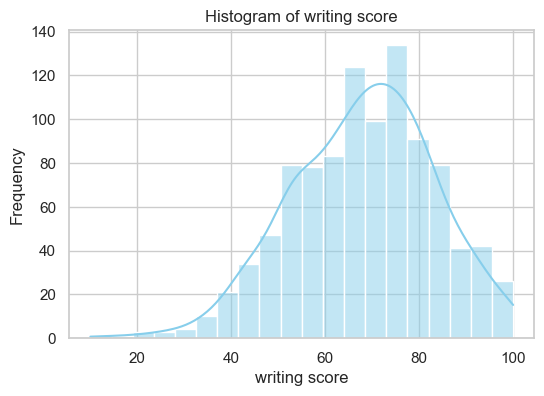

In [7]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


## ⚫ Scatter Plot (نمودار پراکندگی بین ستون‌ها)


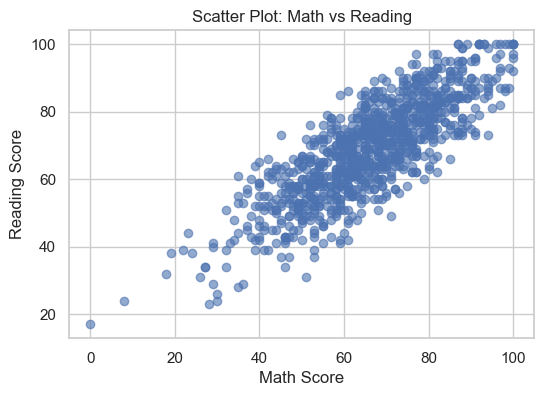

In [8]:
# مثال: ارتباط بین math score و reading score
plt.figure(figsize=(6,4))
plt.scatter(df['math score'], df['reading score'], alpha=0.6)
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.title("Scatter Plot: Math vs Reading")
plt.grid(True)
plt.show()
